# 12.2 prophet

## example 1

In [4]:
from prophet import Prophet
from statsforecast.adapters.prophet import AutoARIMAProphet
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, AutoETS

aus_production = pd.read_csv("../data/tsibbledata/aus_production.csv")
aus_production["ds"] = pd.PeriodIndex(
    aus_production["Quarter"].str.replace(" ", "", regex=False),
    freq="Q"
).to_timestamp()

cement = (
    aus_production.loc[lambda x: x["ds"] >= "1988"]
    [["ds", "Cement"]]
    .rename(columns={"Cement": "y"})
    .assign(unique_id="Cement")
)
train = cement.loc[lambda x: x["ds"] < "2008"]
test = cement.loc[lambda x: x["ds"] >= "2008"]

m = Prophet(weekly_seasonality=False)
m.add_seasonality(name="quarterly", period=4, fourier_order=2)
m.fit(train)

future = m.make_future_dataframe(periods=10, freq="QS")
fc_prophet = (
    m.predict(future)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    .rename(columns={
        "yhat": "Prophet",
        "yhat_lower": "Prophet-lo-80",
        "yhat_upper": "Prophet-hi-80",
    })
)

models = [AutoARIMA(season_length=4), AutoETS(season_length=4)]
sf = StatsForecast(models=models, freq="QS")
level = [80]
fc_stats = sf.forecast(df=train, h=10, level=level)
fc = fc_stats.merge(fc_prophet, on="ds")

11:03:07 - cmdstanpy - INFO - Chain [1] start processing
11:03:07 - cmdstanpy - INFO - Chain [1] done processing


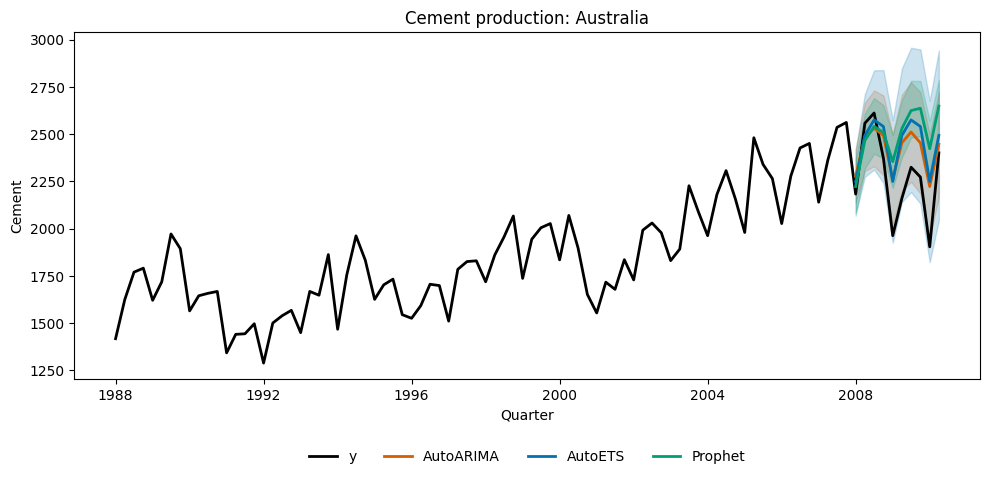

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = {
    "AutoARIMA": "#D55E00",
    "AutoETS": "#0072B2",
    "Prophet": "#009E73",
}

ax.plot(cement["ds"], cement["y"], color="black", linewidth=2, label="y")

for model, color in colors.items():
    ax.fill_between(
        fc["ds"], fc[f"{model}-lo-80"], fc[f"{model}-hi-80"],
        color=color, alpha=0.2,
    )
    ax.plot(fc["ds"], fc[model], color=color, linewidth=2, label=model)

ax.set(xlabel="Quarter", ylabel="Cement", title="Cement production: Australia")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=4, frameon=False)
fig.tight_layout()
plt.show()

In [8]:
from functools import partial
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase

evaluation = (
    evaluate(
        fc.merge(test, on=["unique_id", "ds"]),
        metrics=[rmse, mae, mape, partial(mase, seasonality=4)],
        train_df=cement,
    )
    .drop(columns="unique_id")
    .sort_values("metric")
    .assign(metric=lambda x: x["metric"].str.upper())
    .set_index("metric").rename_axis("")
    .transpose()
    .rename_axis("Method").reset_index()
    .assign(MAPE=lambda x: 100 * x["MAPE"])
)
evaluation

,Method,MAE,MAPE,MASE,RMSE
0,AutoARIMA,169.078247,7.868485,1.124312,195.204245
1,AutoETS,191.151660,8.862344,1.271093,222.180368
2,Prophet,252.961604,11.737873,1.682108,296.025682


## example 2

In [10]:
vic_elec = pd.read_csv("../data/fpp3/vic_elec.csv", parse_dates=["ds"])
vic_demand = (
    vic_elec.loc[lambda x: x["unique_id"] == "Demand"]
    .drop(columns="Holiday")
    .assign(unique_id="VIC")
    [["unique_id", "ds", "y"]]
)
train = vic_demand.iloc[:-48]
test = vic_demand.iloc[-48:]

m = Prophet()
m.add_seasonality(name="hourly", period=48, fourier_order=5)
m.add_seasonality(name="subhourly", period=48 * 7, fourier_order=5)
m.fit(train)

future = m.make_future_dataframe(periods=48 * 2, freq="30min")
fc_prophet = (
    m.predict(future)
    .rename(columns={
        "yhat": "Prophet",
        "yhat_lower": "Prophet-lo-80",
        "yhat_upper": "Prophet-hi-80",
    })
)

renames = {
    "multiplicative_terms": "multiplicative_term",
    "additive_terms": "additive_term",
}
df = (
    fc_prophet.merge(train[["ds", "y"]], on="ds")
    .assign(resid=lambda x: x["y"] - x["Prophet"])
    .rename(columns=renames)
)
columns = ["y", "trend", "multiplicative_term", "additive_term", "resid"]

11:09:12 - cmdstanpy - INFO - Chain [1] start processing
11:09:29 - cmdstanpy - INFO - Chain [1] done processing


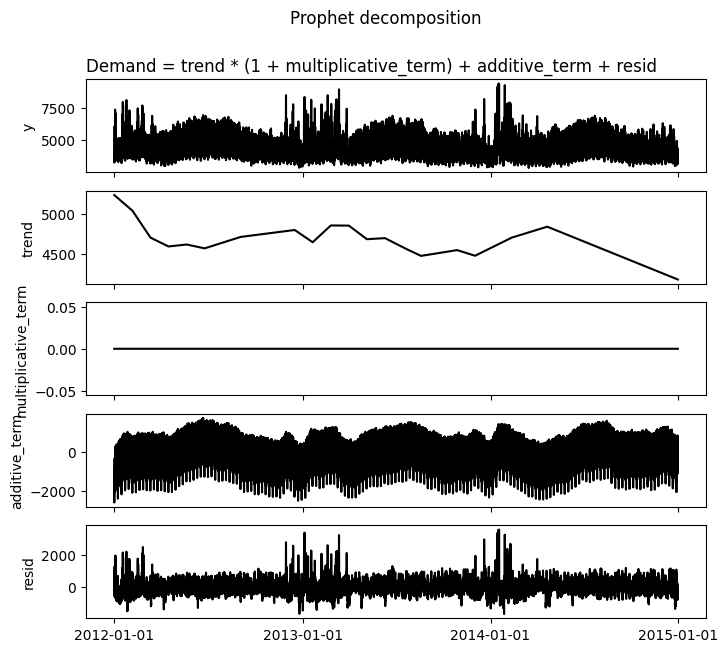

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(5, sharex=True, figsize=(8, 7))
for (ax, column) in zip(axes, columns):
    sns.lineplot(data=df, x="ds", y=column, ax=ax, color="k")
axes[0].set_title(
  "Demand = trend * (1 + multiplicative_term) + additive_term + resid",
  loc="left")
axes[-1].set(xlabel="", xticks=["2012", "2013", "2014", "2015"])
fig.suptitle("Prophet decomposition")
plt.show()

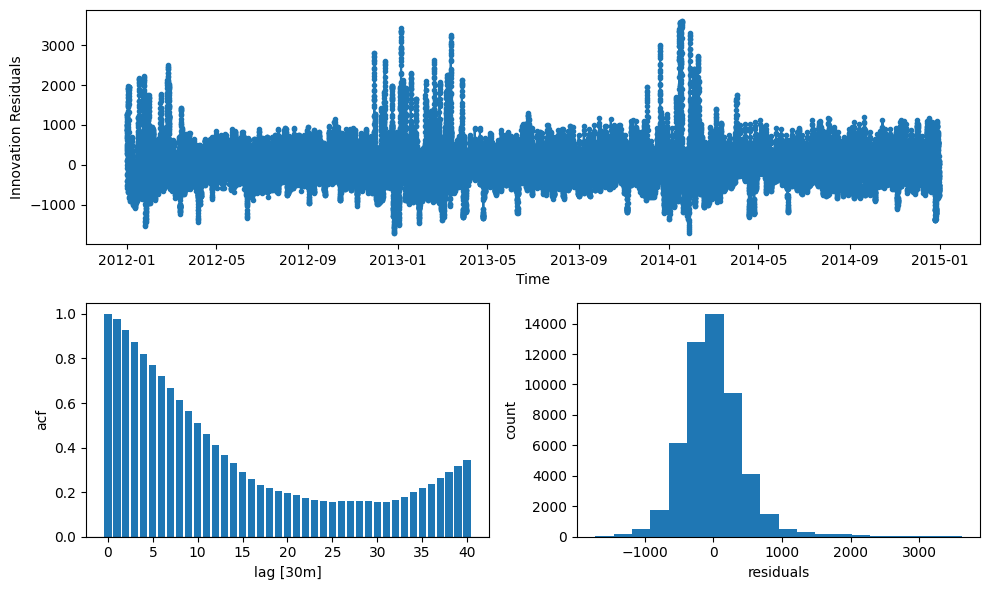

In [13]:
import numpy as np
from matplotlib.ticker import MaxNLocator

resid = df[["ds", "resid"]].dropna()
innov_resid = resid["resid"].to_numpy()

fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(2, 2)
ax_resid = fig.add_subplot(gs[0, :])
ax_acf = fig.add_subplot(gs[1, 0])
ax_hist = fig.add_subplot(gs[1, 1])

ax_resid.plot(resid["ds"], innov_resid, marker=".")
ax_resid.set(xlabel="Time", ylabel="Innovation Residuals")

x = innov_resid - innov_resid.mean()
nlags = min(40, len(x) // 2 - 1)
acf_vals = np.correlate(x, x, mode="full")[len(x) - 1 : len(x) + nlags]
acf_vals = acf_vals / acf_vals[0]
ax_acf.bar(np.arange(nlags + 1), acf_vals)
ax_acf.axhline(0, color="black", linewidth=0.8)
ax_acf.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_acf.set(xlabel="lag [30m]", ylabel="acf")

ax_hist.hist(innov_resid, bins=20)
ax_hist.set(xlabel="residuals", ylabel="count")

fig.tight_layout()
plt.show()

In [16]:
from statsforecast.models import MSTL, AutoARIMA, AutoETS

sf = StatsForecast(models=[MSTL(season_length=[48, 48 * 7])], freq="30min")
level = [80]
fc_stats = sf.forecast(df=train, h=48, level=level)

prophet_columns = ["ds", "Prophet", "Prophet-lo-80", "Prophet-hi-80"]
fc = fc_stats.merge(fc_prophet[prophet_columns], on="ds")

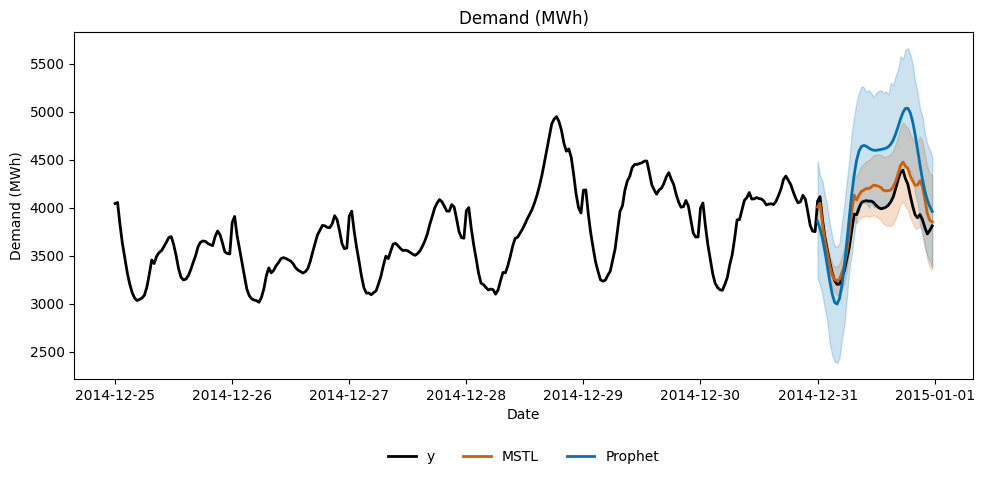

In [18]:
max_insample_length = 48 * 7
history = vic_demand.tail(max_insample_length)

colors = {
    "MSTL": "#D55E00",
    "Prophet": "#0072B2",
}

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(history["ds"], history["y"], color="black", linewidth=2, label="y")

for model, color in colors.items():
    ax.fill_between(
        fc["ds"], fc[f"{model}-lo-80"], fc[f"{model}-hi-80"],
        color=color, alpha=0.2,
    )
    ax.plot(fc["ds"], fc[model], color=color, linewidth=2, label=model)

ax.set(xlabel="Date", ylabel="Demand (MWh)", title="Demand (MWh)")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=3, frameon=False)
fig.tight_layout()
plt.show()

In [19]:
evaluation = (
    evaluate(
        fc.merge(test, on=["unique_id", "ds"]),
        metrics=[rmse, mae, mape, partial(mase, seasonality=4)],
        train_df=train,
    )
    .drop(columns="unique_id")
    .sort_values("metric")
    .assign(metric=lambda x: x["metric"].str.upper())
    .set_index("metric").rename_axis("")
    .transpose()
    .rename_axis("Method").reset_index()
    .assign(MAPE=lambda x: 100 * x["MAPE"])
)
evaluation

,Method,MAE,MAPE,MASE,RMSE
0,MSTL,138.730184,3.528772,0.364257,165.451816
1,Prophet,457.498337,11.507828,1.201232,507.123902
